In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import joblib as jl
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [168]:
df = pd.read_csv("../data/PS_20174392719_1491204439457_log.csv")

In [169]:
df.shape

(6362620, 11)

In [170]:
df.info

<bound method DataFrame.info of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        0   
1

In [171]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [172]:
df.head

<bound method NDFrame.head of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        0   
1  

df.head was used without partheses to showcase all columns

In [173]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [174]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [175]:
df.isnull()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
6362615,False,False,False,False,False,False,False,False,False,False,False
6362616,False,False,False,False,False,False,False,False,False,False,False
6362617,False,False,False,False,False,False,False,False,False,False,False
6362618,False,False,False,False,False,False,False,False,False,False,False


In [176]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Above is the result of checking for missing values

In [177]:
df["isFraud"].value_counts(normalize=True)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

Target distribution of isFraud shows us class imbalance in the dataset. The imbalance we can observe is huge; fraud represents .001% of the recorded transactions in this dataset.

<Axes: xlabel='type', ylabel='count'>

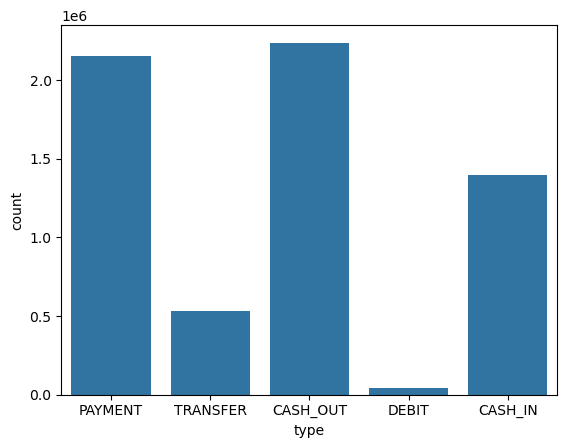

In [178]:
df['type'].value_counts()
sns.countplot(x='type', data=df)

Payment types that are represented the most in the dataset. Keep in mind the y axis is measured in increments of 500,000. This is only the way matplotlib showcases the scale of the data visually.

In [179]:
pd.crosstab(df['type'], df['isFraud'], normalize='index')

isFraud,0,1
type,,
CASH_IN,1.000000,0.000000
CASH_OUT,0.998160,0.001840
DEBIT,1.000000,0.000000
PAYMENT,1.000000,0.000000
TRANSFER,0.992312,0.007688


Checking the amount of fraud per payment method. "Transfer" sticks out as the highest amount that was flagged. Hypothesis that payment method is in some way related to fraud is supported thus far.

<Axes: xlabel='type', ylabel='isFraud'>

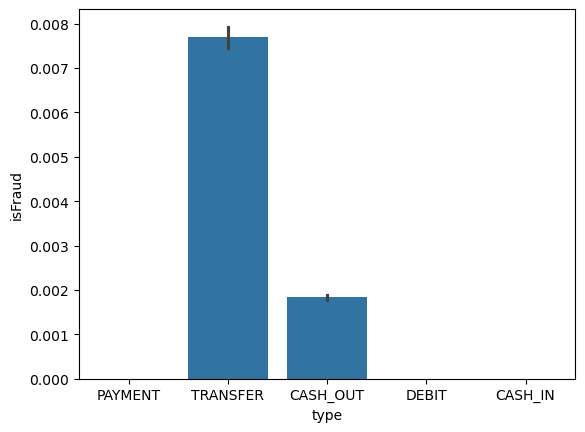

In [180]:
sns.barplot(x="type", y="isFraud", data=df)

This illuminates the connection between the payment methods and the amount of instances the system flagged as fraud. While this is not a concrete metric of determining fraud, one hypothesis based off of the info here would be that "Fraudulent transactions are more likely to occur in transfers compared to other transaction types". Another would be "Larger transactions are more likely to be fraudulent, though not always" given the built-in fraud detection being put in at $200K. Finally, "Balance inconsistencies between expected and sctual amounts would also apply as more likely as more likely to be fraudulent" is a third one that's worth investigating. 

<Axes: xlabel='isFraud', ylabel='amount'>

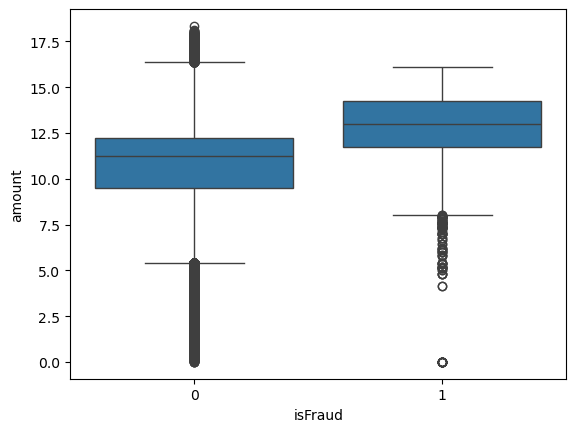

In [182]:
sns.boxplot(x="isFraud", y=np.log1p(df["amount"]), data=df)

The original distribution of transaction amounts was highly right-skewed, with extreme outliers obscuring meaningful comparisons between fraudulent and non-fraudulent transactions. A logarithmic transformation needed to be applied to normalize the distribution and improve interpretability of the box plot.

We can determine that fraud tends to occur at higher transaction amounts, but the major overlap between fraudulent and non-fraudulent distributions indicates that amount alone is not a sufficient predictor. This reinforces the need for using Random Forest to dig deeper into the complex variable relationships at play here.

In [183]:
df.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


Groupby that gives a sense of the mean when observing fraud and non-fraud transactions, among other piece of info like min/max and standard deviation. The means being distinct but similar is going to be a major reason for using Random Forest. 

In [184]:
df['high_amount'] = df['amount'] > 200000
df.groupby('high_amount')['isFraud'].mean()

high_amount
False    0.000585
True     0.003269
Name: isFraud, dtype: float64

This is another indicator of the amount of flagged fraud detected after the threshold of $200K, due to the notably larger amount of "True" values. This will be a useful threshold for the Random Forest to come. 

In [185]:
df['amount_bin'] = pd.qcut(df['amount'], q=10)

df.groupby('amount_bin')['isFraud'].mean()

/var/folders/zb/5xl8h6kd4qx7z31q22wddc840000gn/T/ipykernel_72580/552777237.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('amount_bin')['isFraud'].mean()


amount_bin
(-0.001, 4501.3]             0.000233
(4501.3, 9866.158]           0.000201
(9866.158, 18092.028]        0.000233
(18092.028, 36371.35]        0.000574
(36371.35, 74871.94]         0.000970
(74871.94, 122563.784]       0.000930
(122563.784, 176801.919]     0.000913
(176801.919, 246611.22]      0.000791
(246611.22, 365423.309]      0.001130
(365423.309, 92445516.64]    0.006934
Name: isFraud, dtype: float64

Measuring the continuous feature "amount" by separating it into bins of its own. Around 
$18,000 or so, flagged fraud begins to reach higher levels consistently.

In [186]:
df.groupby(['type', 'high_amount'])['isFraud'].mean()

type      high_amount
CASH_IN   False          0.000000
          True           0.000000
CASH_OUT  False          0.000956
          True           0.003463
DEBIT     False          0.000000
          True           0.000000
PAYMENT   False          0.000000
          True           0.000000
TRANSFER  False          0.010961
          True           0.006697
Name: isFraud, dtype: float64

Large TRANSFERs are fairly dangerous in comparison to other methods, representing somewhere around half of them if these means are to be taken literally.

In [187]:
df['orig_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['dest_diff'] = df['newbalanceDest'] - df['oldbalanceDest']

I'll be analyzing balance mismatches now. The above equations "OldBalanceOrg - NewBalanceOrg ≈ Amount" for the original account and "NewbalanceDest - OldbalanceDest ≈ Amount" for the destination account will offer a way to examine expected transfer amounts vs potentially fraudulent mismatched amounts.

/var/folders/zb/5xl8h6kd4qx7z31q22wddc840000gn/T/ipykernel_72580/967394735.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate = df.groupby('orig_diff_bin')['isFraud'].mean()


<Axes: xlabel='orig_diff_bin'>

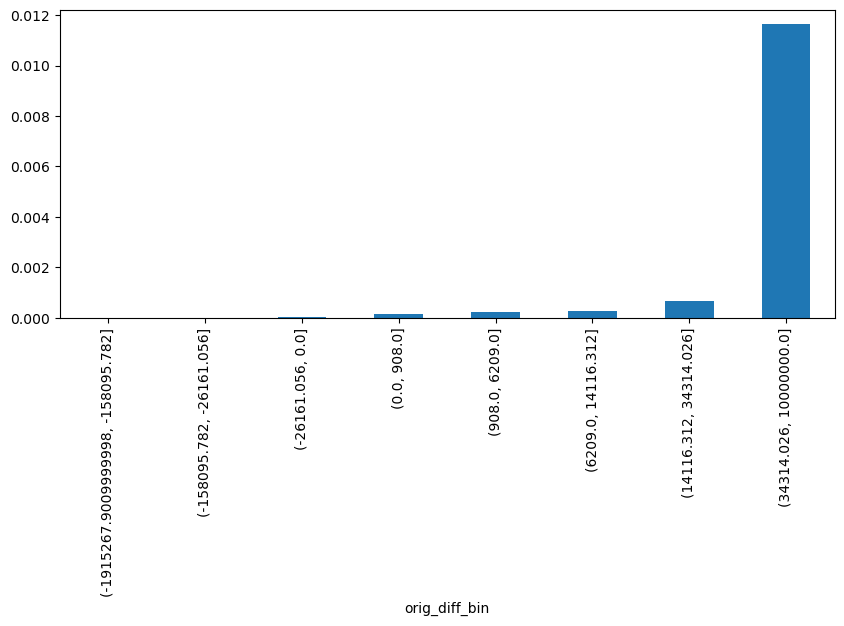

In [188]:
df['orig_diff_bin'] = pd.qcut(df['orig_diff'], 10, duplicates='drop')
fraud_rate = df.groupby('orig_diff_bin')['isFraud'].mean()
fraud_rate.plot(kind='bar', figsize=(10,4))

Dropping duplicates (in this case, all the zeroes) allows us to have a look at this graph now. And so, examining this demonstrates how there is some relation to be found between fraud and the transfer differential as it changes suddenly once it's beyond a certain level.

/var/folders/zb/5xl8h6kd4qx7z31q22wddc840000gn/T/ipykernel_72580/3869836515.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('dest_diff_bin')['isFraud'].mean().plot(kind='bar')


<Axes: xlabel='dest_diff_bin'>

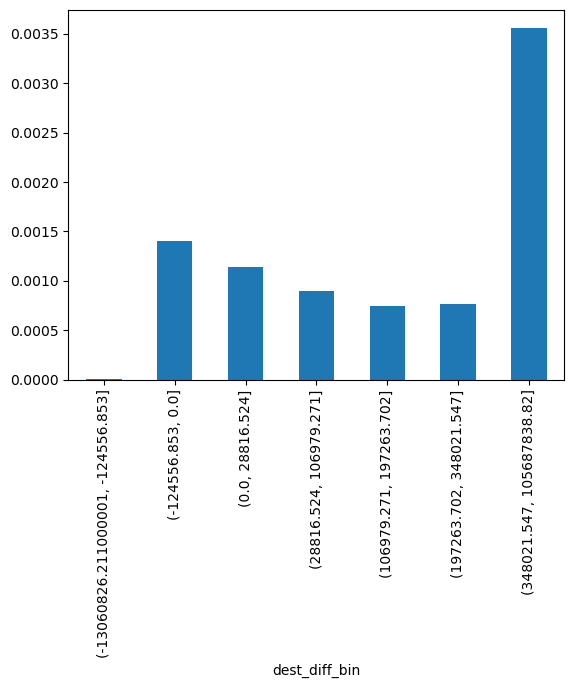

In [189]:
df['dest_diff_bin'] = pd.qcut(df['dest_diff'], 10, duplicates='drop')
df.groupby('dest_diff_bin')['isFraud'].mean().plot(kind='bar')

This here represents destination account discrepancies. Again note how the majority of fraud instances are all the way to the right, though we see a little more variance here overall.

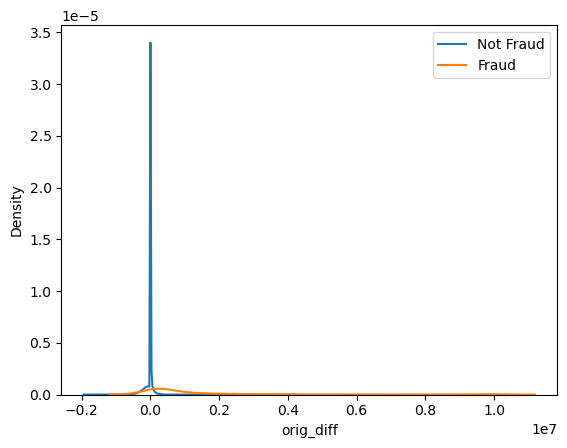

In [195]:
fraud = df[df['isFraud'] == 1]
non_fraud = df[df['isFraud'] == 0]
sns.kdeplot(non_fraud['orig_diff'], label='Not Fraud')
sns.kdeplot(fraud['orig_diff'], label='Fraud')
plt.legend()

In [196]:
df['balance_error'] = abs(df['orig_diff'] - df['amount'])
df.groupby(pd.qcut(df['balance_error'], 10, duplicates='drop'))['isFraud'].mean()

/var/folders/zb/5xl8h6kd4qx7z31q22wddc840000gn/T/ipykernel_72580/1722723799.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['balance_error'], 10, duplicates='drop'))['isFraud'].mean()


balance_error
(-0.001, 1.82e-12]           0.011268
(1.82e-12, 0.01]             0.000044
(0.01, 7538.534]             0.000000
(7538.534, 23555.004]        0.000002
(23555.004, 68677.255]       0.000005
(68677.255, 131234.458]      0.000011
(131234.458, 204553.16]      0.000005
(204553.16, 304920.292]      0.000009
(304920.292, 487768.968]     0.000009
(487768.968, 92445516.64]    0.000030
Name: isFraud, dtype: float64

<Axes: xlabel='amount', ylabel='Density'>

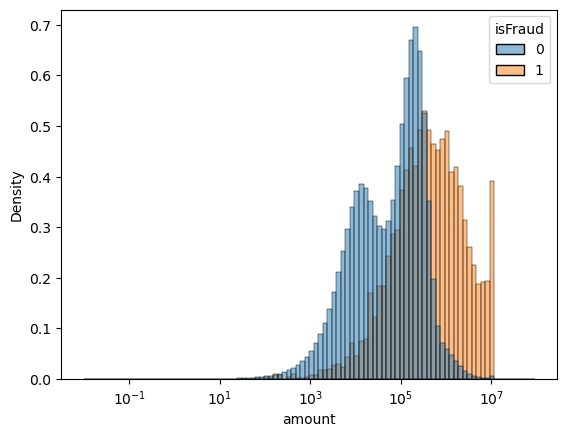

In [204]:
sns.histplot(
    data=df,
    x="amount",
    hue="isFraud",
    bins=100,
    log_scale=True,
    stat="density",
    common_norm=False
)

As a histogram, we can see the clear overlap between fraud and non-fraud instances now, as well as the general amount range where it materializes.

Text(0.5, 1.0, 'Transaction Type vs Fraud (Log Scale)')

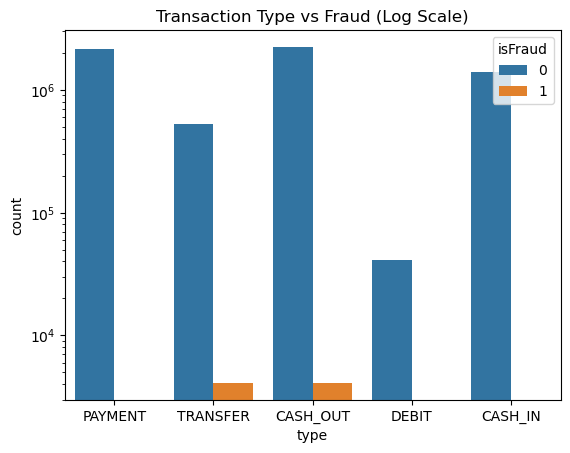

In [212]:
sns.countplot(data=df, x="type", hue="isFraud")
plt.yscale("log")
plt.title("Transaction Type vs Fraud (Log Scale)")

In [214]:
df['is_high_risk_type'] = df['type'].isin(['TRANSFER', 'CASH_OUT']).astype(int)

Noting down the payment types as high risk real quick. Save for later.

Text(0.5, 1.0, 'Fraud Rate by Transaction Type')

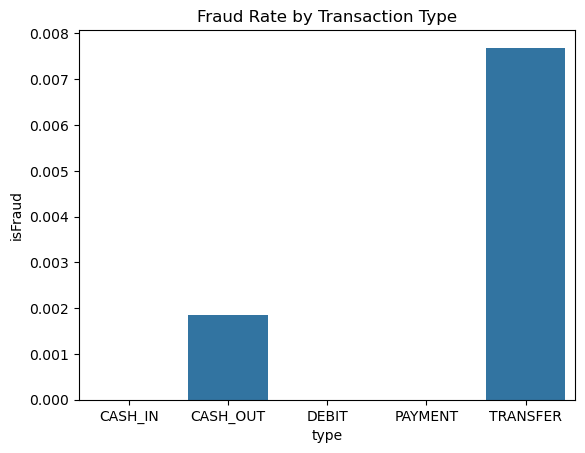

In [217]:
fraud_rate = df.groupby('type')['isFraud'].mean().reset_index()

sns.barplot(data=fraud_rate, x='type', y='isFraud')
plt.title("Fraud Rate by Transaction Type")

This is clearer about the proportion of fraud per payment type. Should be good to work off of.

Coming off of EDA, hypotheses are that high transaction amounts are highly correlated with fraud, that certain payment types are more vulnerable to fraud, and high disparities in expected amounts involving the original and destination accounts in a transfer are especially suspect when identifying fraud.